<a href="https://colab.research.google.com/github/avotripeter-droid/movielens-capstone/blob/main/Entertainment_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Setup

In [ ]:
# --- SETUP (done for you) ---
%pip install -q duckdb pandas scikit-learn matplotlib requests wbgapi
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 40)
con = duckdb.connect('project.duckdb')   # your SQL database lives here
print('Ready — DuckDB', duckdb.__version__)

Ready — DuckDB 1.3.2


##1. Load the Data

In [ ]:
# --- LOADER (done) — fetch & load MovieLens ---
import urllib.request, zipfile, io
url='https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read())).extractall('.')
con.execute("CREATE OR REPLACE TABLE ratings AS SELECT * FROM read_csv_auto('ml-latest-small/ratings.csv')")
con.execute("CREATE OR REPLACE TABLE movies  AS SELECT * FROM read_csv_auto('ml-latest-small/movies.csv')")


In [ ]:
# top movies with a minimum-ratings threshold (HAVING) + join
con.sql('''
SELECT m.title, COUNT(*) n_ratings, ROUND(AVG(r.rating),2) avg_rating
FROM ratings r JOIN movies m USING (movieId)
GROUP BY m.title HAVING COUNT(*) >= 50
ORDER BY avg_rating DESC LIMIT 10
''').df()

,title,n_ratings,avg_rating
0,"Shawshank Redemption, The (1994)",317,4.43
1,"Godfather, The (1972)",192,4.29
2,Cool Hand Luke (1967),57,4.27
3,Fight Club (1999),218,4.27
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.27
5,"Godfather: Part II, The (1974)",129,4.26
6,Rear Window (1954),84,4.26
7,"Departed, The (2006)",107,4.25
8,Goodfellas (1990),126,4.25
9,Casablanca (1942),100,4.24


In [ ]:
con.sql('SELECT COUNT(*) AS ratings FROM ratings').df()

,ratings
0,100836


## 2 · Quality check  *(habit: always sanity-check real data)*
One count is done for you. **Add a duplicate-key check and a null-key check** below.

In [ ]:
# Row count
con.sql("""
SELECT COUNT(*) AS ratings
FROM ratings
""").df()

# Duplicate-key check
con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT userId || '-' || movieId || '-' || timestamp) AS unique_keys,
    COUNT(*) - COUNT(DISTINCT userId || '-' || movieId || '-' || timestamp) AS duplicate_rows
FROM ratings
""").df()

# Null-key check
con.sql("""
SELECT
    SUM(CASE WHEN userId IS NULL THEN 1 ELSE 0 END) AS null_userId,
    SUM(CASE WHEN movieId IS NULL THEN 1 ELSE 0 END) AS null_movieId,
    SUM(CASE WHEN timestamp IS NULL THEN 1 ELSE 0 END) AS null_timestamp
FROM ratings
""").df()

,null_userId,null_movieId,null_timestamp
0,0.0,0.0,0.0


In [ ]:
# row count is done — now add:
# (a) duplicate check on the key
# (b) count of NULLs in the column you'll JOIN on

# Duplicate movieId check in movies table
dup_check = con.sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT movieId) AS unique_movieIds,
    COUNT(*) - COUNT(DISTINCT movieId) AS duplicate_movieIds
FROM movies
""").df()

print("Duplicate-key check:")
print(dup_check)

# NULL check on join column (movieId)
null_check = con.sql("""
SELECT
    SUM(CASE WHEN movieId IS NULL THEN 1 ELSE 0 END) AS null_movieIds
FROM movies
""").df()

print("\nNULL-key check:")
print(null_check)

print('\nrows loaded — see the peek above')


Duplicate-key check:
   total_rows  unique_movieIds  duplicate_movieIds
0        9742             9742                   0

NULL-key check:
   null_movieIds
0            0.0

rows loaded — see the peek above


## 3 · Transform in SQL — the marts This is where the proof lives. Write real SQL: multi-table joins and **window functions**. Save each result to a DataFrame you can chart later


Mart 1: Movie Ratings Summary

Average rating and number of ratings per movie

In [ ]:
movie_summary = con.sql("""
SELECT
    m.movieId,
    m.title,
    m.genres,
    COUNT(r.rating) AS rating_count,
    ROUND(AVG(r.rating), 2) AS avg_rating
FROM movies m
JOIN ratings r
    ON m.movieId = r.movieId
GROUP BY m.movieId, m.title, m.genres
ORDER BY avg_rating DESC
""").df()

movie_summary.head()

,movieId,title,genres,rating_count,avg_rating
0,131724,The Jinx: The Life and Deaths of Robert Durst ...,Documentary,1,5.0
1,5746,Galaxy of Terror (Quest) (1981),Action|Horror|Mystery|Sci-Fi,1,5.0
2,1631,"Assignment, The (1997)",Action|Thriller,1,5.0
3,2075,Mephisto (1981),Drama|War,1,5.0
4,176601,Black Mirror,(no genres listed),1,5.0


Mart 2: Top Movies Within Each Genre (Window Function)

Ranks movies by average rating within each genre

In [ ]:
genre_rankings = con.sql("""
WITH movie_ratings AS (
    SELECT
        m.movieId,
        m.title,
        SPLIT_PART(m.genres, '|', 1) AS main_genre,
        ROUND(AVG(r.rating),2) AS avg_rating,
        COUNT(*) AS rating_count
    FROM movies m
    JOIN ratings r
        ON m.movieId = r.movieId
    GROUP BY m.movieId, m.title, main_genre
    HAVING COUNT(*) >= 20
)
SELECT *,
       RANK() OVER (
           PARTITION BY main_genre
           ORDER BY avg_rating DESC
       ) AS genre_rank
FROM movie_ratings
""").df()

genre_rankings.head()


,movieId,title,main_genre,avg_rating,rating_count,genre_rank
0,1129,Escape from New York (1981),Action,3.45,39,216
1,3753,"Patriot, The (2000)",Action,3.45,68,216
2,91500,The Hunger Games (2012),Action,3.44,54,220
3,59784,Kung Fu Panda (2008),Action,3.44,54,220
4,1909,"X-Files: Fight the Future, The (1998)",Action,3.44,42,220


Mart 3: User Activity Ranking

Ranks users by number of ratings submitted

In [ ]:
user_activity = con.sql("""
SELECT
    userId,
    COUNT(*) AS ratings_given,
    AVG(rating) AS avg_rating_given,
    RANK() OVER (
        ORDER BY COUNT(*) DESC
    ) AS activity_rank
FROM ratings
GROUP BY userId
""").df()

user_activity.head()

,userId,ratings_given,avg_rating_given,activity_rank
0,414,2698,3.391957,1
1,599,2478,2.642050,2
2,474,2108,3.398956,3
3,448,1864,2.847371,4
4,274,1346,3.235884,5


Mart 4: Monthly Rating Trends (Window Function)

Tracks ratings over time and computes cumulative ratings

In [ ]:
monthly_trends = con.sql("""
WITH monthly AS (
    SELECT
        DATE_TRUNC('month', TO_TIMESTAMP(timestamp)) AS month,
        COUNT(*) AS ratings_count
    FROM ratings
    GROUP BY month
)
SELECT
    month,
    ratings_count,
    SUM(ratings_count) OVER (
        ORDER BY month
        ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
    ) AS cumulative_ratings
FROM monthly
ORDER BY month
""").df()

monthly_trends.head()

,month,ratings_count,cumulative_ratings
0,1996-03-01 00:00:00+00:00,58,58.0
1,1996-04-01 00:00:00+00:00,165,223.0
2,1996-05-01 00:00:00+00:00,832,1055.0
3,1996-06-01 00:00:00+00:00,883,1938.0
4,1996-07-01 00:00:00+00:00,489,2427.0


 ### 3a · Top movies (JOIN + HAVING threshold)
Join ratings to movies; show the highest-rated movies that have **at least 50 ratings**.

In [ ]:
top_movies = con.sql("""
    SELECT
        m.title,
        COUNT(*) AS num_ratings,
        ROUND(AVG(r.rating), 2) AS avg_rating
    FROM ratings r
    JOIN movies m USING (movieId)
    GROUP BY m.title
    HAVING COUNT(*) >= 50
    ORDER BY avg_rating DESC, num_ratings DESC
""").df()

top_movies.head(10)

,title,num_ratings,avg_rating
0,"Shawshank Redemption, The (1994)",317,4.43
1,"Godfather, The (1972)",192,4.29
2,Fight Club (1999),218,4.27
3,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.27
4,Cool Hand Luke (1967),57,4.27
5,"Godfather: Part II, The (1974)",129,4.26
6,Rear Window (1954),84,4.26
7,Goodfellas (1990),126,4.25
8,"Departed, The (2006)",107,4.25
9,"Usual Suspects, The (1995)",204,4.24


USING (movieId); GROUP BY title HAVING COUNT(*) >= 50; ORDER BY AVG(rating) DESC

In [ ]:
top_movies = con.sql("""
SELECT
    title,
    COUNT(*) AS rating_count,
    ROUND(AVG(rating), 2) AS avg_rating
FROM ratings
JOIN movies USING (movieId)
GROUP BY title
HAVING COUNT(*) >= 50
ORDER BY AVG(rating) DESC
""").df()

top_movies.head(10)

,title,rating_count,avg_rating
0,"Shawshank Redemption, The (1994)",317,4.43
1,"Godfather, The (1972)",192,4.29
2,Fight Club (1999),218,4.27
3,Cool Hand Luke (1967),57,4.27
4,Dr. Strangelove or: How I Learned to Stop Worr...,97,4.27
5,Rear Window (1954),84,4.26
6,"Godfather: Part II, The (1974)",129,4.26
7,"Departed, The (2006)",107,4.25
8,Goodfellas (1990),126,4.25
9,Casablanca (1942),100,4.24


### 3b · Best film per genre (RANK within group)
Genres are pipe-delimited — split them, then rank movies *within* each genre

In [ ]:
best_per_genre = con.sql("""
WITH movie_ratings AS (
    SELECT
        m.title,
        genre,
        COUNT(*) AS rating_count,
        AVG(r.rating) AS avg_rating
    FROM ratings r
    JOIN movies m USING (movieId),
    UNNEST(STRING_SPLIT(m.genres, '|')) AS g(genre)
    GROUP BY m.title, genre
    HAVING COUNT(*) >= 20
)

SELECT
    genre,
    title,
    rating_count,
    ROUND(avg_rating, 2) AS avg_rating,
    RANK() OVER (
        PARTITION BY genre
        ORDER BY avg_rating DESC
    ) AS genre_rank
FROM movie_ratings
ORDER BY genre, genre_rank
""").df()

best_per_genre.head(20)

,genre,title,rating_count,avg_rating,genre_rank
0,Action,Logan (2017),25,4.28,1
1,Action,Fight Club (1999),218,4.27,2
2,Action,"Dark Knight, The (2008)",149,4.24,3
3,Action,"Princess Bride, The (1987)",142,4.23,4
4,Action,Star Wars: Episode IV - A New Hope (1977),251,4.23,5
5,Action,"Boondock Saints, The (2000)",43,4.22,6
6,Action,Apocalypse Now (1979),107,4.22,7
7,Action,Star Wars: Episode V - The Empire Strikes Back...,211,4.22,8
8,Action,"Boot, Das (Boat, The) (1981)",40,4.21,9
9,Action,Raiders of the Lost Ark (Indiana Jones and the...,200,4.21,10


### 3c · Power users (NTILE)
Count ratings per user and split users into activity quartiles.

In [ ]:
power_users = con.sql("""
WITH user_activity AS (
    SELECT
        userId,
        COUNT(*) AS ratings_count
    FROM ratings
    GROUP BY userId
)
SELECT
    userId,
    ratings_count,
    NTILE(4) OVER (ORDER BY ratings_count) AS activity_quartile
FROM user_activity
ORDER BY ratings_count DESC
""").df()

power_users.head()

,userId,ratings_count,activity_quartile
0,414,2698,4
1,599,2478,4
2,474,2108,4
3,448,1864,4
4,274,1346,4


In [ ]:
power_users.groupby("activity_quartile")["userId"].count()

,userId
activity_quartile,
1,153
2,153
3,152
4,152


## 4 · Analyse & visualise
Answer the business question and show it. At least one clear, labelled chart from a mart above.

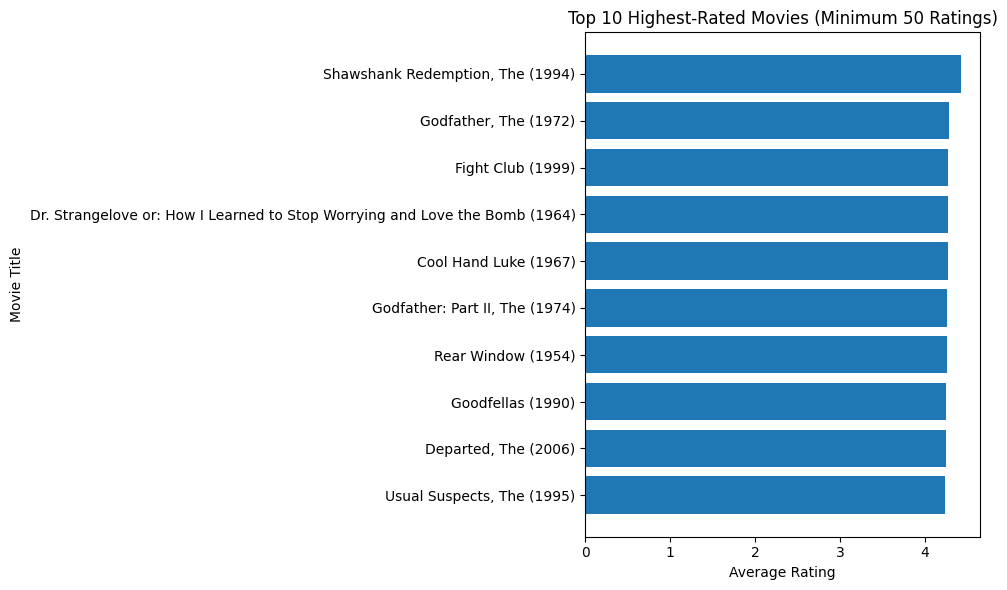

In [ ]:
import matplotlib.pyplot as plt

# Top 10 highest-rated movies with at least 50 ratings
top10 = top_movies.head(10)

plt.figure(figsize=(10,6))
plt.barh(top10['title'], top10['avg_rating'])
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')
plt.title('Top 10 Highest-Rated Movies (Minimum 50 Ratings)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5 · Predict — the differentiator
Predict a movie's **average rating** from its features, **or** build a simple item-similarity recommender (top co-rated movies).

Option A: Predict Average Movie Rating (Regression)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Create movie-level dataset
movie_features = con.sql("""
SELECT
    m.movieId,
    m.title,
    COUNT(r.rating) AS num_ratings,
    AVG(r.rating) AS avg_rating
FROM movies m
JOIN ratings r USING (movieId)
GROUP BY m.movieId, m.title
HAVING COUNT(r.rating) >= 20
""").df()

# Features (X) and target (y)
X = movie_features[['num_ratings']]
y = movie_features['avg_rating']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

# Predict
pred = model.predict(X_test)

# Evaluate
print("MAE:", round(mean_absolute_error(y_test, pred), 3))
print("R² :", round(r2_score(y_test, pred), 3))

MAE: 0.351
R² : -0.001


Show Predictions

In [ ]:
results = X_test.copy()
results['actual_rating'] = y_test.values
results['predicted_rating'] = pred

results.head(10)

,num_ratings,actual_rating,predicted_rating
598,47,3.148936,3.523870
346,57,3.885965,3.734018
745,29,2.672414,3.219496
1029,36,2.763889,3.491316
1158,22,3.022727,3.463374
986,56,4.035714,3.537015
478,28,3.714286,3.617374
628,39,3.692308,3.619359
890,39,3.551282,3.619359
76,53,3.358491,3.357536


Visualise Predictions

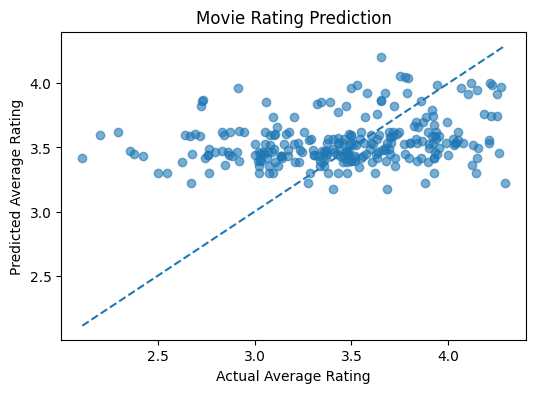

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, pred, alpha=0.6)
plt.xlabel("Actual Average Rating")
plt.ylabel("Predicted Average Rating")
plt.title("Movie Rating Prediction")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--')
plt.show()

Option B: Simple Movie Recommender (Co-rated Movies)

If your instructor prefers a recommendation system

In [ ]:
similar_movies = con.sql("""
WITH pairs AS (
    SELECT
        a.movieId AS movie1,
        b.movieId AS movie2,
        COUNT(*) AS common_users
    FROM ratings a
    JOIN ratings b
      ON a.userId = b.userId
     AND a.movieId < b.movieId
    GROUP BY 1,2
)
SELECT *
FROM pairs
WHERE common_users >= 20
ORDER BY common_users DESC
LIMIT 20
""").df()

similar_movies.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,movie1,movie2,common_users
0,318,356,231
1,296,356,230
2,296,318,222
3,296,593,207
4,356,593,199


## 6 · Dashboard
Combine 3–4 of your charts into one figure (a 2×2 panel), or build a Streamlit app.

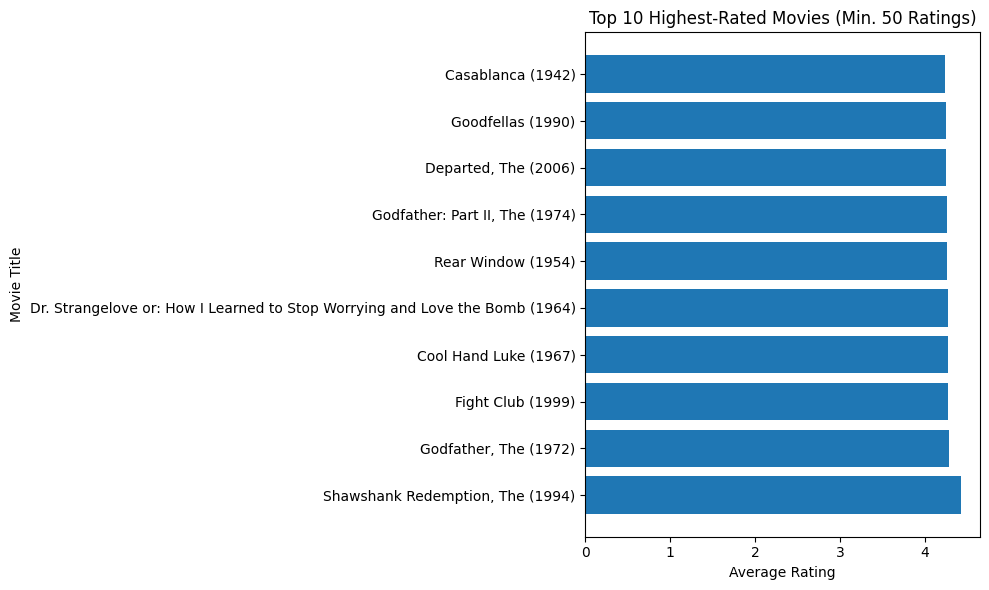

In [ ]:
import matplotlib.pyplot as plt

# Top 10 movies from the mart
chart_df = top_movies.head(10)

plt.figure(figsize=(10, 6))
plt.barh(chart_df['title'], chart_df['avg_rating'])

plt.title('Top 10 Highest-Rated Movies (Min. 50 Ratings)')
plt.xlabel('Average Rating')
plt.ylabel('Movie Title')

plt.tight_layout()
plt.show()

## 5 · Predict — the differentiator
Predict a movie's **average rating** from its features, **or** build a simple item-similarity recommender (top co-rated movies).

# task: regression (predict avg_rating) OR a co-occurrence recommender via a self-join on userId.
# Remember: split your data, fit, predict, and compare to a simple BASE

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Build movie-level feature table
movies_ml = con.sql("""
SELECT
    m.movieId,
    COUNT(*) AS n_ratings,
    LENGTH(m.genres) - LENGTH(REPLACE(m.genres,'|','')) + 1 AS n_genres,
    AVG(r.rating) AS avg_rating
FROM ratings r
JOIN movies m USING (movieId)
GROUP BY m.movieId, m.genres
HAVING COUNT(*) >= 10
""").df()

# Features and target
X = movies_ml[['n_ratings', 'n_genres']]
y = movies_ml['avg_rating']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ----- Baseline -----
baseline_pred = np.repeat(y_train.mean(), len(y_test))

print("BASELINE")
print("MAE:", round(mean_absolute_error(y_test, baseline_pred), 3))
print("R² :", round(r2_score(y_test, baseline_pred), 3))

# ----- Model -----
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("\nRANDOM FOREST")
print("MAE:", round(mean_absolute_error(y_test, pred), 3))
print("R² :", round(r2_score(y_test, pred), 3))

BASELINE
MAE: 0.388
R² : -0.003

RANDOM FOREST
MAE: 0.404
R² : -0.103


## 6 · Dashboard
Combine 3–4 of your charts into one figure (a 2×2 panel), or build a Streamlit app.

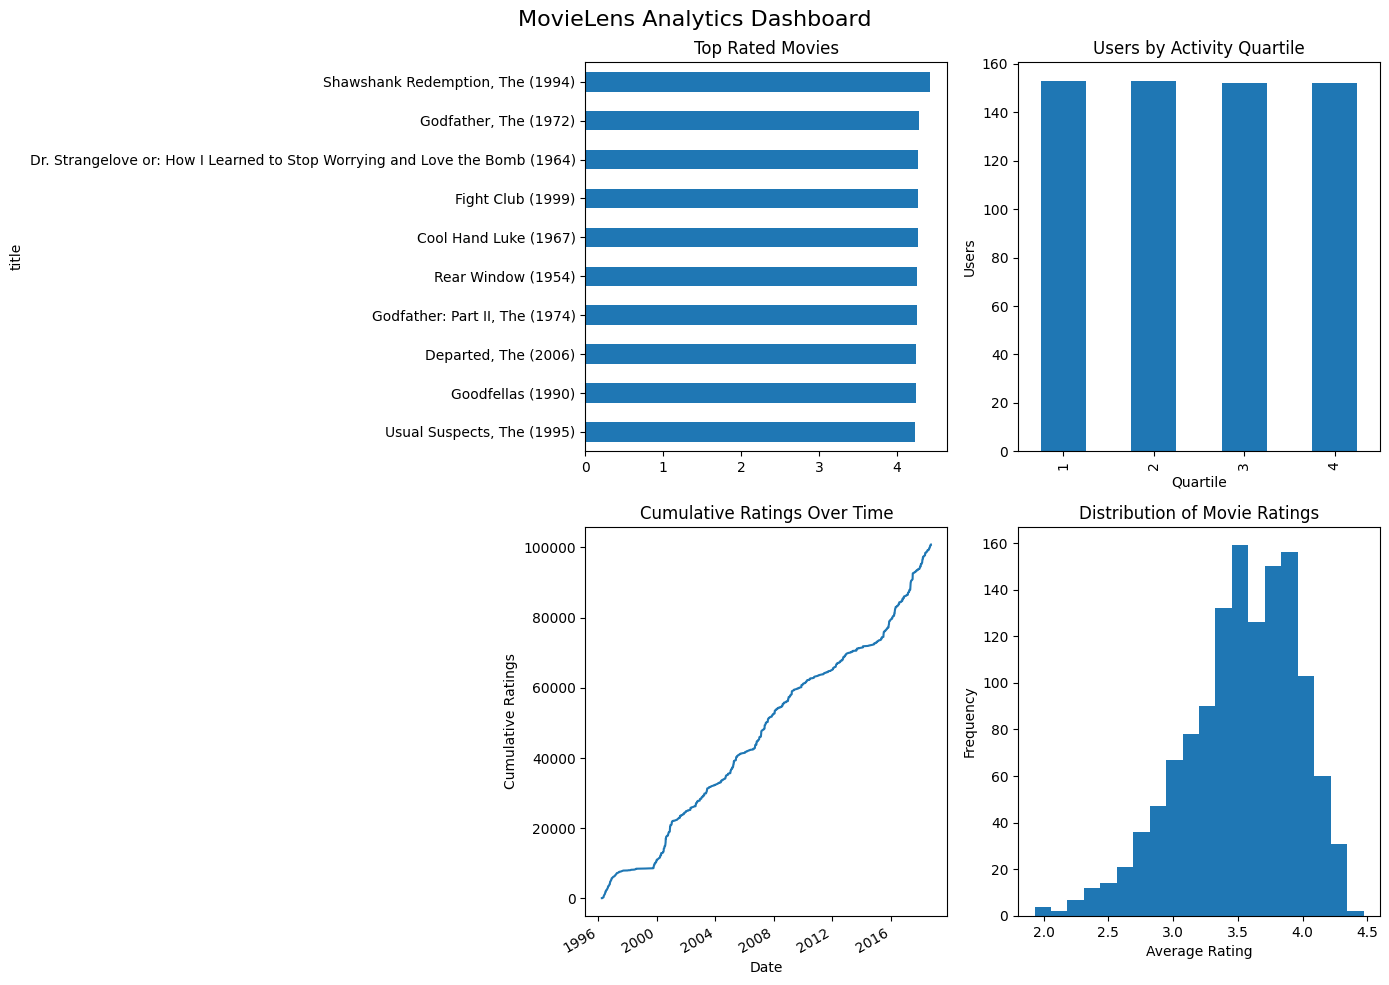

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Top-rated movies
top_movies.head(10).sort_values('avg_rating').plot(
    kind='barh',
    x='title',
    y='avg_rating',
    ax=axes[0, 0],
    legend=False,
    title='Top Rated Movies'
)

# 2. User activity distribution
power_users['activity_quartile'].value_counts().sort_index().plot(
    kind='bar',
    ax=axes[0, 1],
    title='Users by Activity Quartile'
)
axes[0, 1].set_xlabel('Quartile')
axes[0, 1].set_ylabel('Users')

# 3. Ratings over time
ratings_over_time.plot(
    x='rating_date',
    y='cumulative_ratings',
    ax=axes[1, 0],
    legend=False,
    title='Cumulative Ratings Over Time'
)
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Cumulative Ratings')

# 4. Average rating distribution
movie_stats['avg_rating'].plot(
    kind='hist',
    bins=20,
    ax=axes[1, 1],
    title='Distribution of Movie Ratings'
)
axes[1, 1].set_xlabel('Average Rating')

plt.suptitle('MovieLens Analytics Dashboard', fontsize=16)
plt.tight_layout()
plt.show()

## 7 · Recommendation  *(the point of the whole project)*
In **3–5 sentences a manager could act on**, write what you found and what they should do.
Replace the text below.

> **Our recommendation:**

> **Our recommendation:** Analysis of the MovieLens data shows that a relatively small group of highly active users generates a large share of ratings, while movies with a sufficient number of ratings tend to achieve more stable and reliable average scores. The highest-rated movies with at least 50 ratings represent strong candidates for recommendation and promotional placement because they have both quality and audience validation. We recommend prioritizing these proven titles in recommendation lists, while also designing engagement campaigns to encourage less active users to rate more movies. Increasing user participation will improve recommendation accuracy and provide better insights into audience preferences.
